In [36]:
#21.543.468-0 Ulises Alarcon miercoles 6 de mayo



import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
# Configuración global de Seaborn
sns.set_theme(
style='whitegrid',
palette='muted',
font_scale=1.2
)
# Carga del dataset
df = pd.read_csv('cafeteria_universitaria_s8.csv')

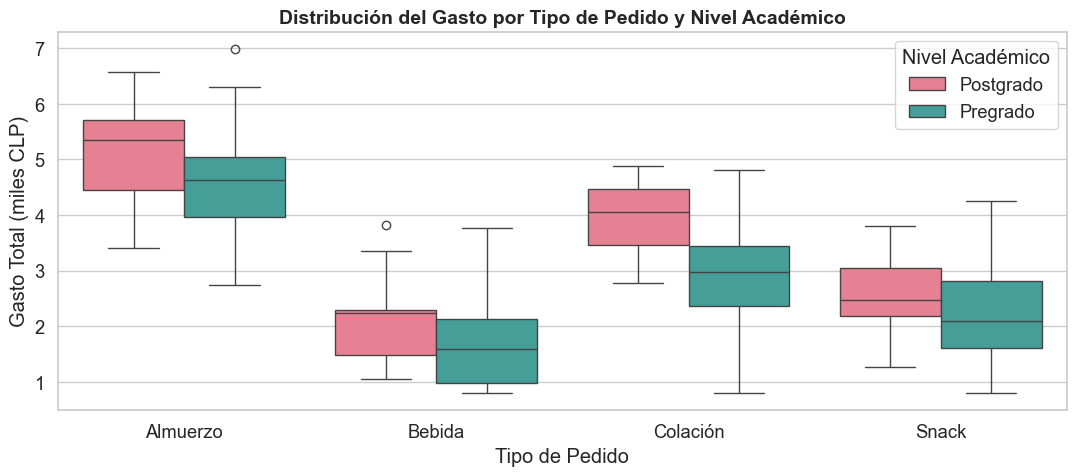

In [37]:
fig, ax = plt.subplots(figsize=(11, 5))

sns.boxplot(
    data=df,                
    x='tipo_pedido',         
    y='gasto_total',          
    hue='nivel_academico',   
    palette = 'husl',           
    order=sorted(df['tipo_pedido'].unique()), 
    ax=ax,
    #showfliers=False
    #notch=True
    #width=0.4
    #orient='h'

)

ax.set_title(
    'Distribución del Gasto por Tipo de Pedido y Nivel Académico',
    fontsize=14,
    fontweight='bold'
)
ax.set_xlabel('Tipo de Pedido')
ax.set_ylabel('Gasto Total (miles CLP)')

ax.legend(title='Nivel Académico', loc='upper right')

plt.tight_layout()
plt.show()

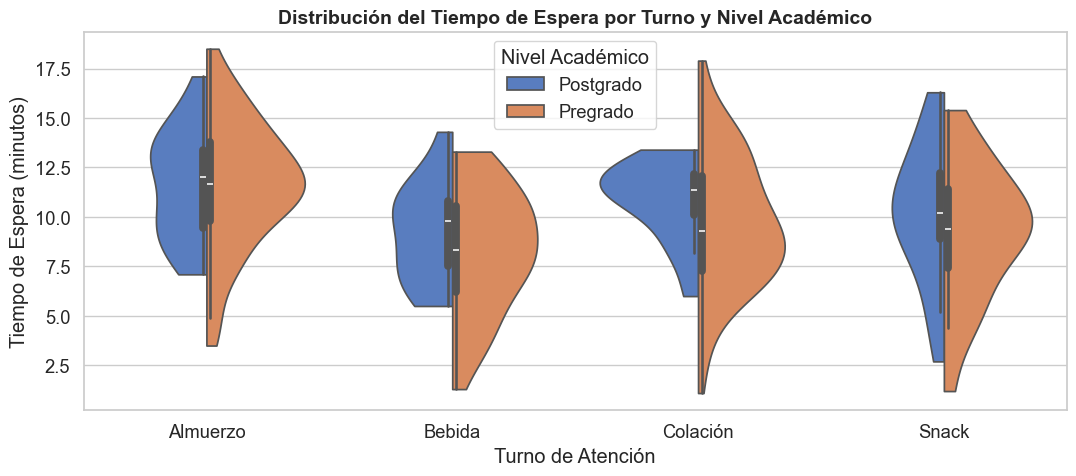

In [38]:
fig, ax = plt.subplots(figsize=(11, 5))
sns.violinplot(
    data=df,
    x="tipo_pedido",
    y="tiempo_espera_min",
    hue="nivel_academico",
    split=True,
    inner="box",
    #inner="quartile",
    #inner="point",
    #inner="stick",
    #inner="None",
    cut=0,
    #cut=2,
    palette="muted",
    order=sorted(df["tipo_pedido"].unique()),
    ax=ax
)
ax.set_title(
    "Distribución del Tiempo de Espera por Turno y Nivel Académico",
    fontsize=14,
    fontweight="bold"
)
ax.set_xlabel("Turno de Atención")
ax.set_ylabel("Tiempo de Espera (minutos)")
ax.legend(title="Nivel Académico")

plt.tight_layout()
plt.show()

Variables numéricas: ['semana_mes', 'gasto_total', 'tiempo_espera_min', 'calificacion_servicio', 'items_pedido', 'propina_porcentaje']

Matriz de correlación:
                       semana_mes  gasto_total  tiempo_espera_min  \
semana_mes                   1.00        -0.03              -0.07   
gasto_total                 -0.03         1.00               0.49   
tiempo_espera_min           -0.07         0.49               1.00   
calificacion_servicio        0.07        -0.16              -0.24   
items_pedido                -0.08         0.30               0.15   
propina_porcentaje           0.00         0.02              -0.04   

                       calificacion_servicio  items_pedido  propina_porcentaje  
semana_mes                              0.07         -0.08                0.00  
gasto_total                            -0.16          0.30                0.02  
tiempo_espera_min                      -0.24          0.15               -0.04  
calificacion_servicio            

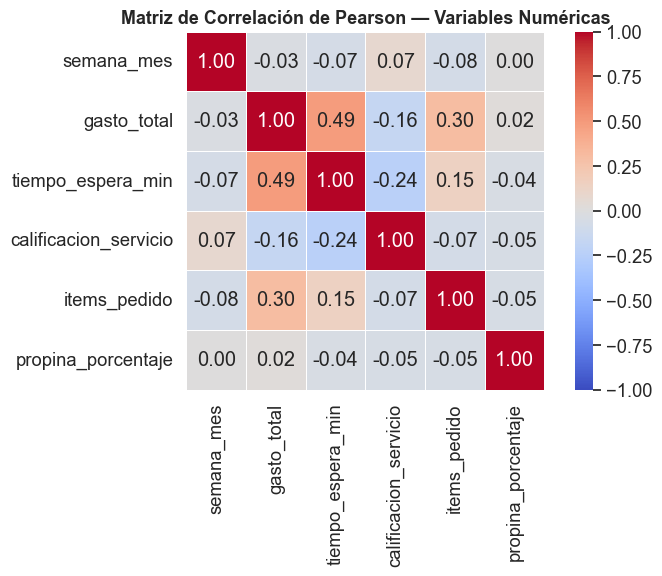

In [39]:
# Paso 1: Seleccionar solo columnas numéricas
num_cols = df.select_dtypes(include='number')
print('Variables numéricas:', list(num_cols.columns))

# Paso 2: Calcular la matriz de correlación de Pearson
corr_matrix = num_cols.corr()
print('\nMatriz de correlación:')
print(corr_matrix.round(2))

# Paso 3: Visualizar como heatmap
fig, ax = plt.subplots(figsize=(8, 6))

sns.heatmap(
    data=corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    linecolor='white',
    square=True,
    ax=ax
)

ax.set_title(
    'Matriz de Correlación de Pearson — Variables Numéricas',
    fontsize=13,
    fontweight='bold'
)

plt.tight_layout()
plt.show()


/home/ulises/jupyter-env/lib/python3.14/site-packages/seaborn/axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)
/home/ulises/jupyter-env/lib/python3.14/site-packages/seaborn/axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)
/home/ulises/jupyter-env/lib/python3.14/site-packages/seaborn/axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)
/home/ulises/jupyter-env/lib/python3.14/site-packages/seaborn/axisgrid.py:854: FutureWarning: 

Passing `palette

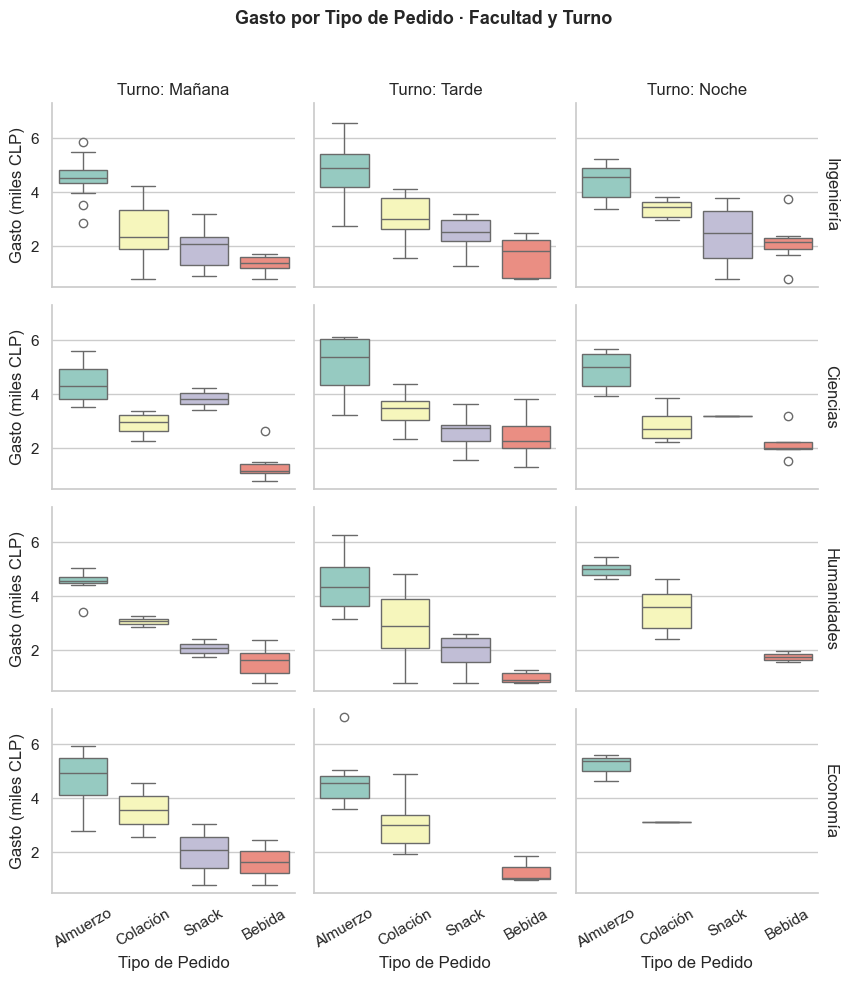

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', font_scale=1.0)

g = sns.FacetGrid(
    df,
    col='turno',                     # ajusta si tu columna se llama distinto
    row='facultad',                 # ajusta si tu columna se llama distinto
    col_order=['Mañana', 'Tarde', 'Noche'],
    row_order=['Ingeniería', 'Ciencias', 'Humanidades', 'Economía'],
    height=2.4,
    aspect=1.2,
    margin_titles=True
)

g.map_dataframe(
    sns.boxplot,
    x='tipo_pedido',
    y='gasto_total',
    palette='Set3',
    order=['Almuerzo', 'Colación', 'Snack', 'Bebida']
)

g.set_axis_labels('Tipo de Pedido', 'Gasto (miles CLP)')
g.set_titles(
    col_template='Turno: {col_name}',
    row_template='{row_name}'
)

g.figure.suptitle(
    'Gasto por Tipo de Pedido · Facultad y Turno',
    y=1.02,
    fontsize=13,
    fontweight='bold'
)

for ax in g.axes.flat:
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
g.savefig('act4_facetgrid.png', dpi=300, bbox_inches='tight')
plt.show()

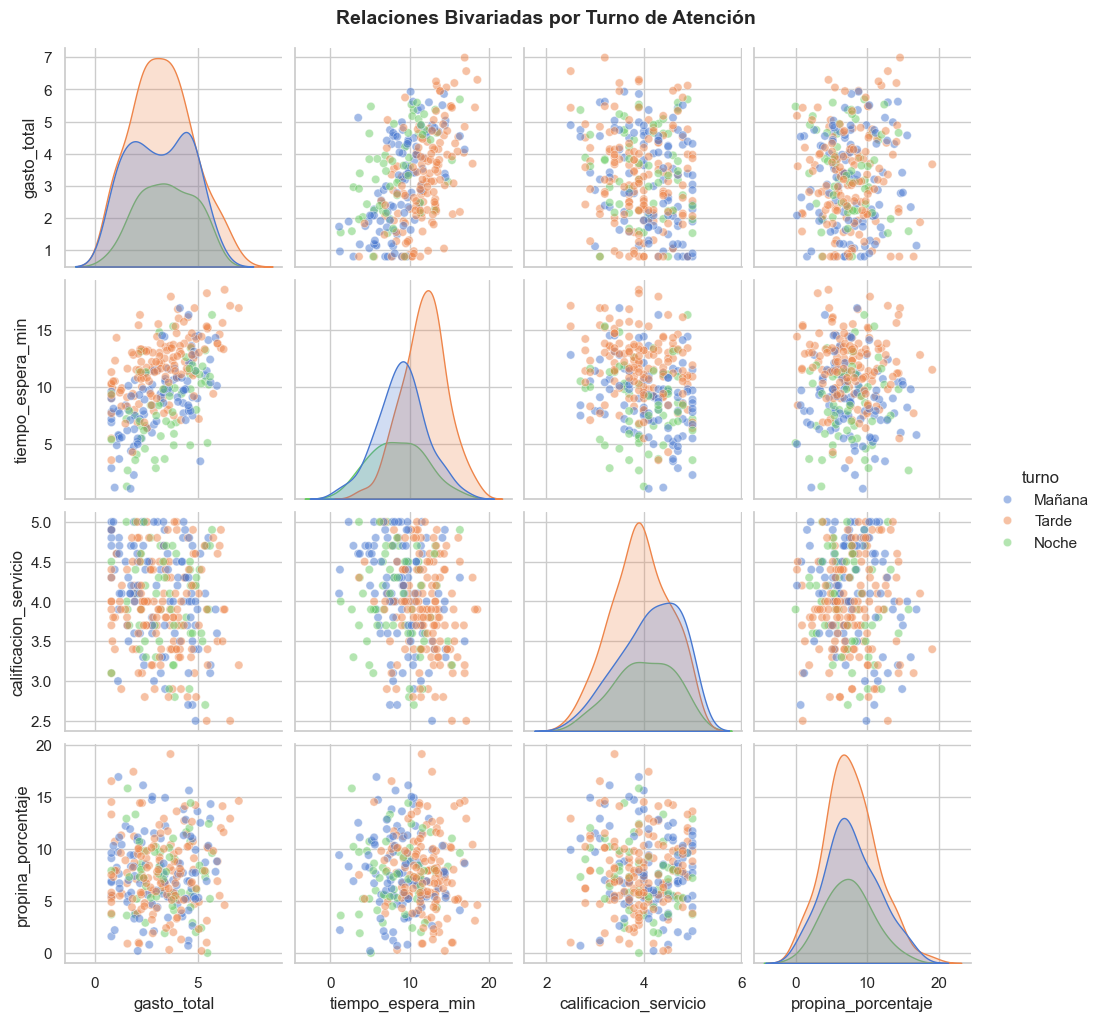

In [41]:
# Seleccionar variables numéricas de interés
vars_plot = [
    'gasto_total',
    'tiempo_espera_min',
    'calificacion_servicio',
    'propina_porcentaje'
]

g = sns.pairplot(
    df[vars_plot + ['turno']],
    hue='turno',
    hue_order=['Mañana', 'Tarde', 'Noche'],
    diag_kind='kde',
    plot_kws={'alpha': 0.5},
    palette='muted'
)

g.figure.suptitle(
    'Relaciones Bivariadas por Turno de Atención',
    y=1.02,
    fontsize=14,
    fontweight='bold'
)

g.savefig('desafio_pairplot.svg', bbox_inches='tight')  # SVG = calidad vectorial
plt.show()